# Experiment Comparison Notebook

Compare multiple experiment configs side-by-side on:

| Priority | Metric | Abbr |
|---|---|---|
| Primary | Cumulative Return | CR |
| Secondary | Sharpe Ratio | SR |
| Secondary | Maximum Drawdown | MD |
| Secondary | Daily Volatility | DV |
| Secondary | Annualized Volatility | AV |

**DB**: `/Users/maximilianheil/OMSCS/data/deepfund.db`

## 1. Setup

In [1]:
import os
import sys
import importlib
import json
import sqlite3
from pathlib import Path

os.environ["DB_PATH"] = "/Users/maximilianheil/OMSCS/data/deepfund.db"

project_root = Path().absolute().parent.parent
decision_making_dir = project_root / "decision_making"
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(decision_making_dir))
os.chdir(decision_making_dir)

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import decision_making.analysis.performance as perf_module
import decision_making.analysis.queries as query_module

importlib.reload(perf_module)
importlib.reload(query_module)

from decision_making.analysis.performance import (
    calculate_annualized_return,
    calculate_buy_hold_benchmark,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_timing_performance,
)
from decision_making.analysis.queries import get_experiment_metadata
from decision_making.database.sqlite_helper import SQLiteDB

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 10

C = {
    "TSLA": "#E31E24",
    "BTC": "#F7931A",
    "benchmark": "#888888",
}
# Color cycle for experiments
EXP_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

print(f"Working dir : {os.getcwd()}")
print(f"DB_PATH     : {os.environ['DB_PATH']}")
print("Setup complete.")

Working dir : /Users/maximilianheil/OMSCS/finmmeval-task3-2026 copy/decision_making
DB_PATH     : /Users/maximilianheil/OMSCS/data/deepfund.db
Setup complete.


## 2. Discover Available Experiments

In [2]:
conn = sqlite3.connect(os.environ["DB_PATH"])
conn.row_factory = sqlite3.Row
cur = conn.cursor()
cur.execute("""
    SELECT c.exp_name, c.tickers, c.llm_model,
           COUNT(DISTINCT p.id) as days,
           MIN(p.trading_date) as start_date,
           MAX(p.trading_date) as end_date,
           COUNT(DISTINCT d.id) as decisions
    FROM config c
    LEFT JOIN portfolio p ON p.config_id = c.id
    LEFT JOIN decision d ON d.portfolio_id = p.id
    GROUP BY c.id ORDER BY c.exp_name
""")
all_experiments = [dict(r) for r in cur.fetchall()]
conn.close()

print(f"Found {len(all_experiments)} experiment(s) in DB:\n")
print(f"{'#':<4} {'exp_name':<42} {'days':>5} {'start':>12} {'end':>12} {'decisions':>10} {'model'}")
print("-" * 100)
for i, e in enumerate(all_experiments):
    print(
        f"{i:<4} {e['exp_name']:<42} {e['days']:>5} "
        f"{(e['start_date'] or '')[:10]:>12} {(e['end_date'] or '')[:10]:>12} "
        f"{e['decisions']:>10}  {e['llm_model']}"
    )

Found 8 experiment(s) in DB:

#    exp_name                                    days        start          end  decisions model
----------------------------------------------------------------------------------------------------
0    ablation_company_news_enhanced               362   2024-08-02   2026-01-09        722  gpt-4.1-nano
1    ablation_enhanced_memory                     361   2024-08-02   2026-01-09        722  gpt-4.1-nano
2    ablation_ml_model                            361   2024-08-02   2026-01-09        722  gpt-4.1-nano
3    ablation_section_news                        361   2024-08-02   2026-01-09        722  gpt-4.1-nano
4    all_tools_tsla_btc                           361   2024-08-02   2026-01-09        722  gpt-4o-mini
5    dev                                           19   2024-08-02   2024-08-28         38  gpt-4o-mini
6    enhanced_tools_tsla_btc                      361   2024-08-02   2026-01-09        722  gpt-4.1-nano
7    tesla_btc_baseline                

## 3. Select Experiments & Tickers

Edit `COMPARE_EXPERIMENTS` and `COMPARE_TICKERS` below, then re-run all cells.

In [3]:
# ── Configure here ─────────────────────────────────────────────────────────
COMPARE_EXPERIMENTS = [
    "tesla_btc_baseline",
    "ablation_company_news_enhanced",
    "ablation_ml_model",
    "ablation_enhanced_memory",
    "enhanced_tools_tsla_btc",
    "all_tools_tsla_btc",
    "ablation_section_news",
]

COMPARE_TICKERS = ["TSLA", "BTC"]  # leave empty [] to auto-detect from first experiment
# ───────────────────────────────────────────────────────────────────────────

db = SQLiteDB()

# Validate
valid = []
for name in COMPARE_EXPERIMENTS:
    cid = db.get_config_id_by_name(name)
    if cid:
        valid.append((name, cid))
        print(f"  OK  {name}  (config_id={cid})")
    else:
        print(f"  !!  '{name}' not found in DB — skipping")

if not valid:
    raise RuntimeError("No valid experiments found. Check COMPARE_EXPERIMENTS.")

# Auto-detect tickers from first valid experiment
if not COMPARE_TICKERS:
    meta0 = get_experiment_metadata(db, valid[0][1])
    COMPARE_TICKERS = json.loads(meta0["tickers"]) if isinstance(meta0["tickers"], str) else meta0["tickers"]

print(f"\nExperiments : {[n for n, _ in valid]}")
print(f"Tickers     : {COMPARE_TICKERS}")

  OK  tesla_btc_baseline  (config_id=c3daab94-1223-439a-a391-b2609b164989)
  OK  ablation_company_news_enhanced  (config_id=44099258-65ce-4001-b47a-e2fa21758aa4)
  OK  ablation_ml_model  (config_id=d0a36ce0-296f-4a21-88f7-e5edcf8e28f0)
  OK  ablation_enhanced_memory  (config_id=c362c90c-090e-433e-a9fe-f9c1b6dc2eea)
  OK  enhanced_tools_tsla_btc  (config_id=9b4fad87-484d-4b40-a5e5-6a753adf8691)
  OK  all_tools_tsla_btc  (config_id=f3cbdbd5-7a23-4d5e-875f-ab3dac8338ec)
  OK  ablation_section_news  (config_id=c26bb27b-58fe-4c10-92da-8ddce9dd685f)

Experiments : ['tesla_btc_baseline', 'ablation_company_news_enhanced', 'ablation_ml_model', 'ablation_enhanced_memory', 'enhanced_tools_tsla_btc', 'all_tools_tsla_btc', 'ablation_section_news']
Tickers     : ['TSLA', 'BTC']


## 4. Compute Metrics

For each experiment × ticker:
- **CR** — final cumulative return (%)
- **SR** — annualized Sharpe ratio (252 trading days)
- **MD** — maximum drawdown (%)
- **DV** — daily volatility = std of daily timing returns (%)
- **AV** — annualized volatility = DV × √252 (%)

In [4]:
results = {}  # key: (exp_name, ticker) → dict of metrics + perf DataFrame
benchmarks = {}  # key: ticker → buy-and-hold DataFrame


def compute_metrics(perf_df: pl.DataFrame, meta: dict) -> dict:
    """Compute all five metrics from a timing-performance DataFrame."""
    ret = perf_df["timing_return_pct"]
    cum_ret = perf_df["cumulative_return_pct"]

    cr = float(cum_ret[-1])
    sr = calculate_sharpe_ratio(ret)

    # Max drawdown on cumulative wealth index
    wealth = pl.Series([(1 + r / 100) for r in ret.cum_sum().to_list()])
    md, _, _ = calculate_max_drawdown(wealth)

    # Daily & annualized volatility
    ret_np = ret.drop_nulls().to_numpy()
    dv = float(np.std(ret_np, ddof=1)) if len(ret_np) > 1 else 0.0
    av = dv * np.sqrt(252)

    num_days = (meta["end_date"] - meta["start_date"]).days
    ann_ret = calculate_annualized_return(cr, num_days)

    return dict(CR=cr, SR=sr, MD=md, DV=dv, AV=av, Ann_Ret=ann_ret)


for exp_name, cid in valid:
    meta = get_experiment_metadata(db, cid)
    for ticker in COMPARE_TICKERS:
        perf = calculate_timing_performance(db, cid, ticker)
        if perf is None or len(perf) == 0:
            print(f"  SKIP  {exp_name} / {ticker} — no decisions")
            continue
        if perf["trading_date"].dtype == pl.Utf8:
            perf = perf.with_columns(pl.col("trading_date").str.to_datetime())

        metrics = compute_metrics(perf, meta)
        results[(exp_name, ticker)] = {"metrics": metrics, "perf": perf, "meta": meta}
        print(
            f"  {exp_name:42s} {ticker}  "
            f"CR={metrics['CR']:+7.2f}%  SR={metrics['SR']:+.3f}  "
            f"MD={metrics['MD']:+6.2f}%  DV={metrics['DV']:.3f}%  AV={metrics['AV']:.2f}%"
        )

        # Benchmark (compute once per ticker)
        if ticker not in benchmarks:
            try:
                benchmarks[ticker] = calculate_buy_hold_benchmark(ticker, meta["start_date"], meta["end_date"])
            except Exception as e:
                print(f"  Benchmark error {ticker}: {e}")

print(f"\nLoaded {len(results)} (experiment, ticker) pair(s).")

  tesla_btc_baseline                         TSLA  CR= -54.48%  SR=-0.755  MD=-65.84%  DV=3.351%  AV=53.19%
  tesla_btc_baseline                         BTC  CR= -17.97%  SR=-0.293  MD=-32.51%  DV=1.941%  AV=30.81%
  ablation_company_news_enhanced             TSLA  CR= -23.53%  SR=-0.134  MD=-53.70%  DV=3.058%  AV=48.54%
  ablation_company_news_enhanced             BTC  CR= -18.53%  SR=-0.299  MD=-40.57%  DV=1.973%  AV=31.33%
  ablation_ml_model                          TSLA  CR= -23.79%  SR=-0.446  MD=-41.49%  DV=1.955%  AV=31.03%
  ablation_ml_model                          BTC  CR=  +0.83%  SR=+0.154  MD=-26.70%  DV=1.645%  AV=26.12%
  ablation_enhanced_memory                   TSLA  CR= -61.76%  SR=-1.135  MD=-88.17%  DV=3.051%  AV=48.44%
  ablation_enhanced_memory                   BTC  CR= -15.90%  SR=-0.271  MD=-32.47%  DV=1.823%  AV=28.94%
  enhanced_tools_tsla_btc                    TSLA  CR= -31.87%  SR=-0.371  MD=-74.18%  DV=2.818%  AV=44.74%
  enhanced_tools_tsla_btc       

## 5. Summary Metrics Table

In [5]:
rows = []
for (exp_name, ticker), data in results.items():
    m = data["metrics"]
    rows.append({
        "Experiment": exp_name,
        "Ticker": ticker,
        "CR (%)": round(m["CR"], 2),
        "Ann. Ret (%)": round(m["Ann_Ret"], 2),
        "SR": round(m["SR"], 3),
        "MD (%)": round(m["MD"], 2),
        "DV (%)": round(m["DV"], 3),
        "AV (%)": round(m["AV"], 2),
    })

# Add buy-and-hold benchmarks
for ticker, bm in benchmarks.items():
    bm_pd = bm.to_pandas()
    bm_ret_series = pl.Series(bm_pd["cumulative_return_pct"].diff().dropna().values)
    bm_cr = float(bm_pd["cumulative_return_pct"].iloc[-1])
    bm_sr = calculate_sharpe_ratio(bm_ret_series)
    bm_md, _, _ = calculate_max_drawdown(bm["portfolio_value"])
    bm_ret_np = bm_pd["cumulative_return_pct"].diff().dropna().values
    bm_dv = float(np.std(bm_ret_np, ddof=1)) if len(bm_ret_np) > 1 else 0.0
    bm_av = bm_dv * np.sqrt(252)
    # Use date range from first valid experiment's meta
    first_meta = next(iter(results.values()))["meta"]
    bm_ann = calculate_annualized_return(bm_cr, (first_meta["end_date"] - first_meta["start_date"]).days)
    rows.append({
        "Experiment": f"Buy-and-Hold ({ticker})",
        "Ticker": ticker,
        "CR (%)": round(bm_cr, 2),
        "Ann. Ret (%)": round(bm_ann, 2),
        "SR": round(bm_sr, 3),
        "MD (%)": round(bm_md, 2),
        "DV (%)": round(bm_dv, 3),
        "AV (%)": round(bm_av, 2),
    })

summary_df = pd.DataFrame(rows)


# Styled display: green = best, red = worst per numeric column
def highlight_best(s):
    """Green = best, red = worst. For MD lower (less negative) is better."""
    if s.name in ("MD (%)", "DV (%)", "AV (%)"):
        best, worst = s.idxmax(), s.idxmin()  # higher MD (less negative) = better
    else:
        best, worst = s.idxmax(), s.idxmin()
    colors = [""] * len(s)
    colors[best] = "background-color: #d4edda; color: #155724"
    colors[worst] = "background-color: #f8d7da; color: #721c24"
    return colors


num_cols = ["CR (%)", "Ann. Ret (%)", "SR", "MD (%)", "DV (%)", "AV (%)"]
display(
    summary_df.style
    .apply(highlight_best, subset=num_cols)
    .format({c: "{:.3f}" for c in num_cols})
    .set_caption("Experiment Comparison — all metrics (green = best, red = worst per column)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

,Experiment,Ticker,CR (%),Ann. Ret (%),SR,MD (%),DV (%),AV (%)
0,tesla_btc_baseline,TSLA,-54.480,-42.140,-0.755,-65.840,3.351,53.190
1,tesla_btc_baseline,BTC,-17.970,-12.860,-0.293,-32.510,1.941,30.810
2,ablation_company_news_enhanced,TSLA,-23.530,-17.010,-0.134,-53.700,3.058,48.540
3,ablation_company_news_enhanced,BTC,-18.530,-13.280,-0.299,-40.570,1.973,31.330
4,ablation_ml_model,TSLA,-23.790,-17.210,-0.446,-41.490,1.955,31.030
5,ablation_ml_model,BTC,0.830,0.580,0.154,-26.700,1.645,26.120
6,ablation_enhanced_memory,TSLA,-61.760,-48.740,-1.135,-88.170,3.051,48.440
7,ablation_enhanced_memory,BTC,-15.900,-11.340,-0.271,-32.470,1.823,28.940
8,enhanced_tools_tsla_btc,TSLA,-31.870,-23.420,-0.371,-74.180,2.818,44.740
9,enhanced_tools_tsla_btc,BTC,11.240,7.690,0.403,-18.390,1.796,28.510


## 6. Cumulative Return (Primary Metric)

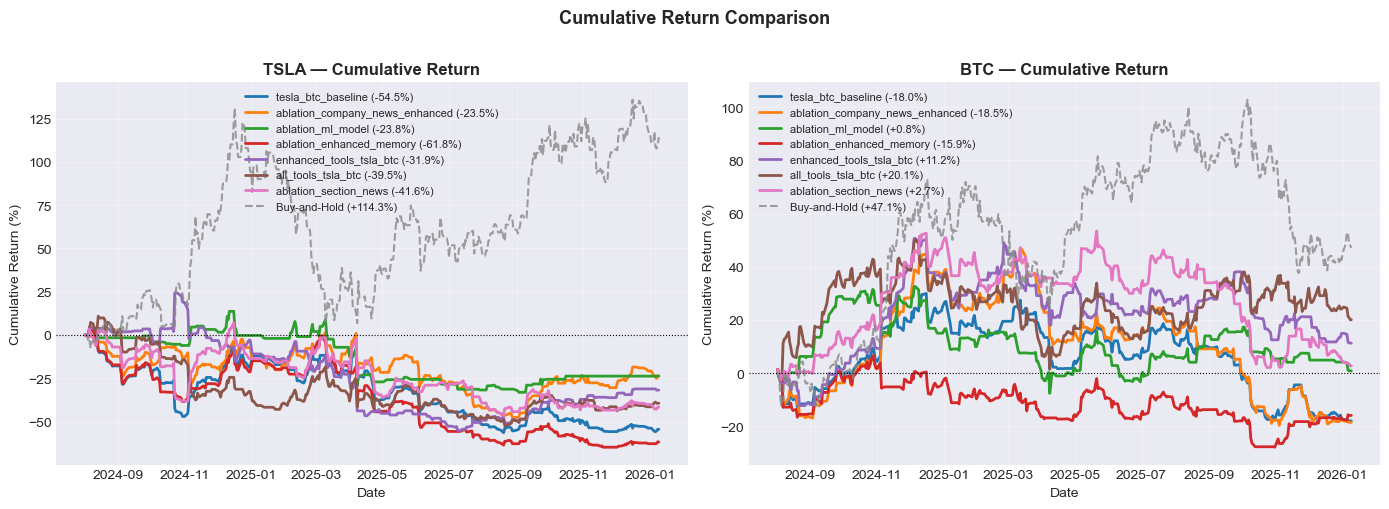

In [6]:
fig, axes = plt.subplots(1, len(COMPARE_TICKERS), figsize=(7 * len(COMPARE_TICKERS), 5), sharey=False)
if len(COMPARE_TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, COMPARE_TICKERS):
    exp_entries = [(n, d) for (n, t), d in results.items() if t == ticker]

    for i, (exp_name, data) in enumerate(exp_entries):
        perf = data["perf"].to_pandas()
        color = EXP_COLORS[i % len(EXP_COLORS)]
        cr_final = data["metrics"]["CR"]
        ax.plot(
            perf["trading_date"],
            perf["cumulative_return_pct"],
            linewidth=2,
            color=color,
            label=f"{exp_name} ({cr_final:+.1f}%)",
        )

    if ticker in benchmarks:
        bm = benchmarks[ticker].to_pandas()
        bm_cr = bm["cumulative_return_pct"].iloc[-1]
        ax.plot(
            bm["date"],
            bm["cumulative_return_pct"],
            color=C["benchmark"],
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label=f"Buy-and-Hold ({bm_cr:+.1f}%)",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{ticker} — Cumulative Return", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Return (%)")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

plt.suptitle("Cumulative Return Comparison", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Drawdown Curves (MD)

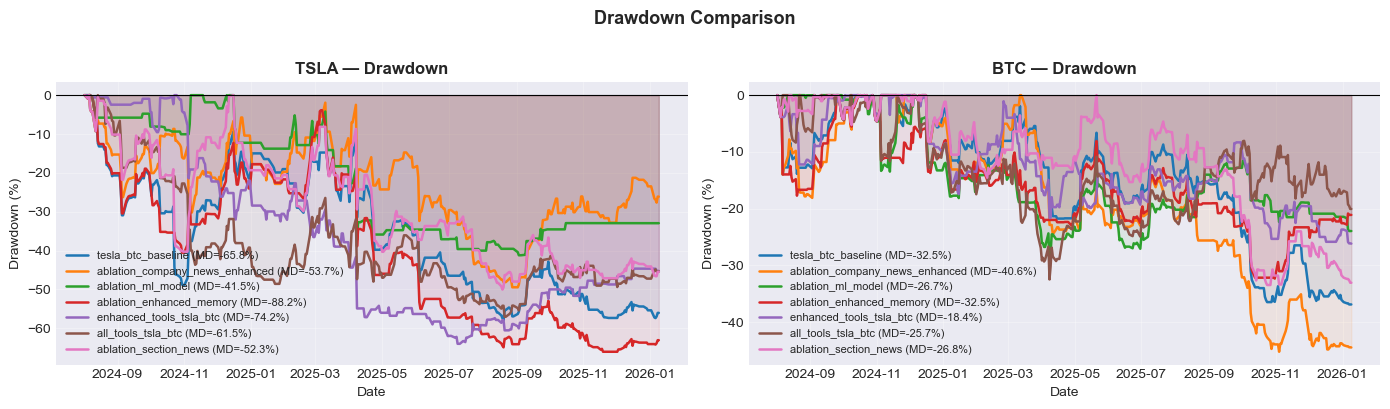

In [7]:
fig, axes = plt.subplots(1, len(COMPARE_TICKERS), figsize=(7 * len(COMPARE_TICKERS), 4), sharey=False)
if len(COMPARE_TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, COMPARE_TICKERS):
    exp_entries = [(n, d) for (n, t), d in results.items() if t == ticker]

    for i, (exp_name, data) in enumerate(exp_entries):
        ret_np = data["perf"]["timing_return_pct"].to_numpy() / 100.0
        wealth = np.cumprod(1 + ret_np)
        peak = np.maximum.accumulate(wealth)
        dd = (wealth - peak) / peak * 100
        dates = data["perf"]["trading_date"].to_pandas()

        color = EXP_COLORS[i % len(EXP_COLORS)]
        md = data["metrics"]["MD"]
        ax.plot(dates, dd, linewidth=1.8, color=color, label=f"{exp_name} (MD={md:.1f}%)")
        ax.fill_between(dates, dd, 0, color=color, alpha=0.08)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{ticker} — Drawdown", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Drawdown Comparison", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Secondary Metrics Bar Charts (SR, MD, DV, AV)

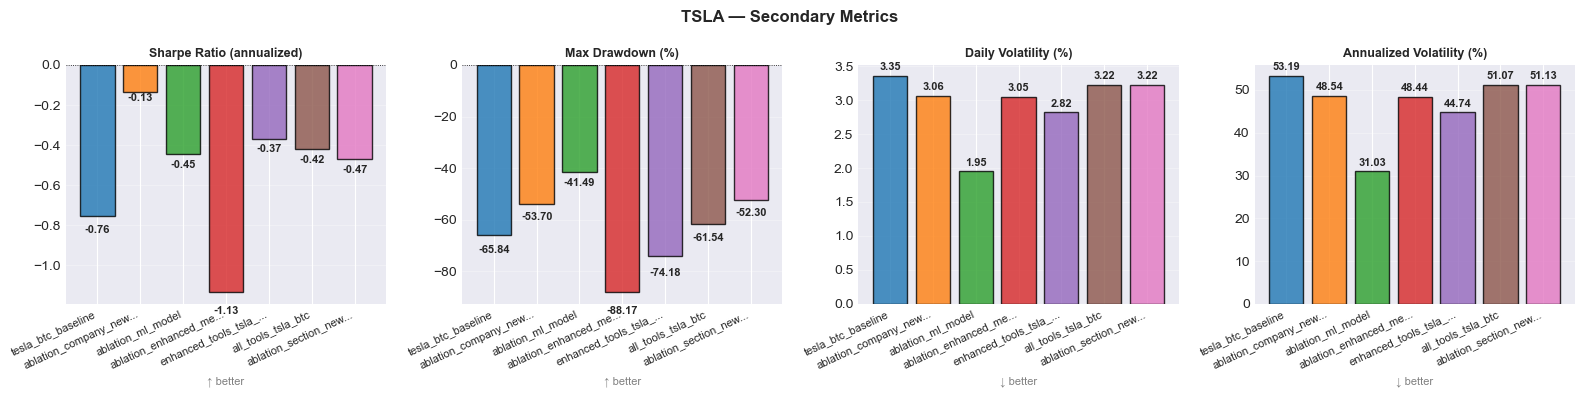

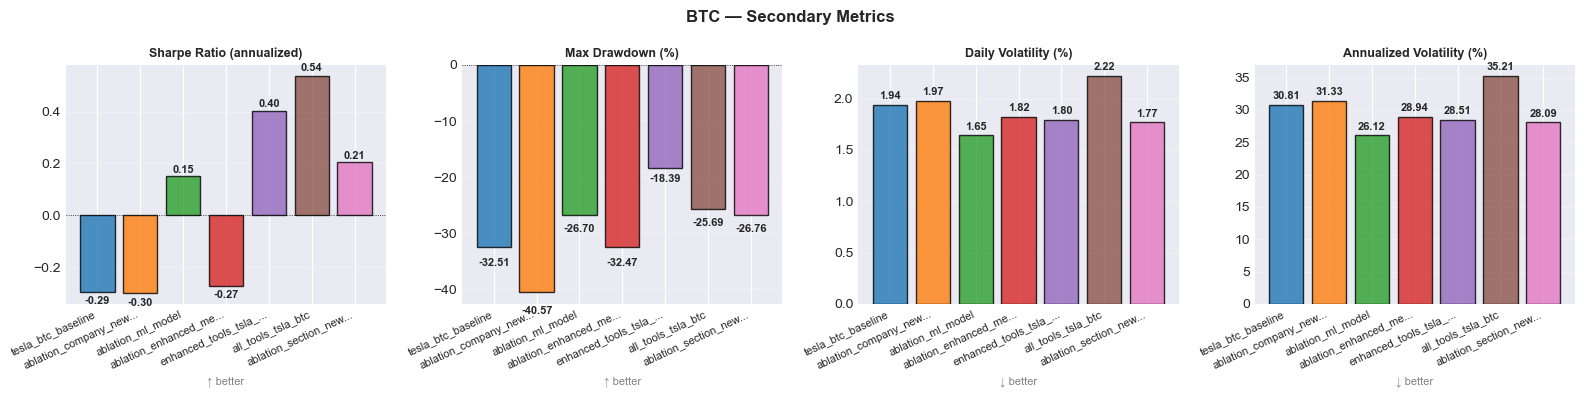

In [8]:
METRIC_DEFS = [
    ("SR", "Sharpe Ratio (annualized)", True),  # (key, label, higher-is-better)
    ("MD", "Max Drawdown (%)", True),  # less negative = better
    ("DV", "Daily Volatility (%)", False),  # lower = better
    ("AV", "Annualized Volatility (%)", False),
]

for ticker in COMPARE_TICKERS:
    exp_entries = [(n, d) for (n, t), d in results.items() if t == ticker]
    if not exp_entries:
        continue

    fig, axes = plt.subplots(1, len(METRIC_DEFS), figsize=(4 * len(METRIC_DEFS), 4))

    for ax, (key, label, higher_better) in zip(axes, METRIC_DEFS):
        names = [n for n, _ in exp_entries]
        vals = [d["metrics"][key] for _, d in exp_entries]
        colors = EXP_COLORS[: len(names)]

        bars = ax.bar(range(len(names)), vals, color=colors, alpha=0.8, edgecolor="black")
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels([n[:20] + "..." if len(n) > 20 else n for n in names], rotation=25, ha="right", fontsize=8)
        ax.set_title(label, fontweight="bold", fontsize=9)
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
        ax.grid(axis="y", alpha=0.3)

        # Annotate values
        for bar, v in zip(bars, vals):
            offset = max(abs(v) * 0.02, 0.002)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + (offset if v >= 0 else -offset * 3),
                f"{v:.2f}",
                ha="center",
                va="bottom" if v >= 0 else "top",
                fontsize=8,
                fontweight="bold",
            )

        arrow = "↑ better" if higher_better else "↓ better"
        ax.set_xlabel(arrow, fontsize=8, color="gray")

    plt.suptitle(f"{ticker} — Secondary Metrics", fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Rank Heatmap

Rank experiments per metric (rank 1 = best). Lower rank number is better.

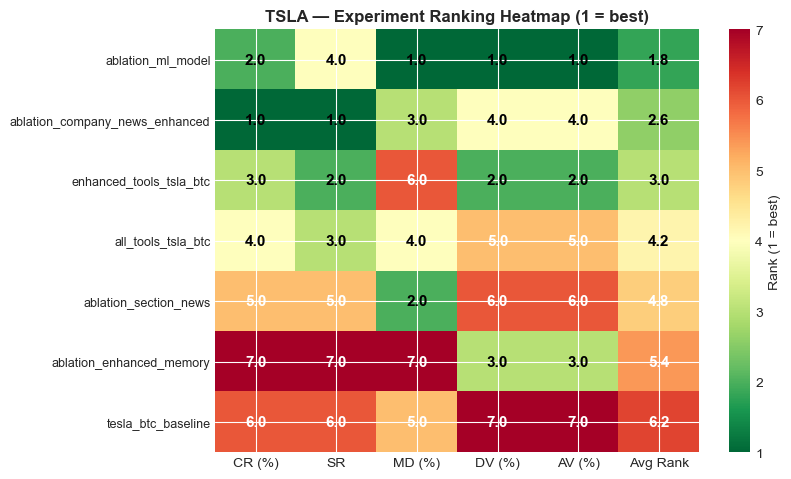

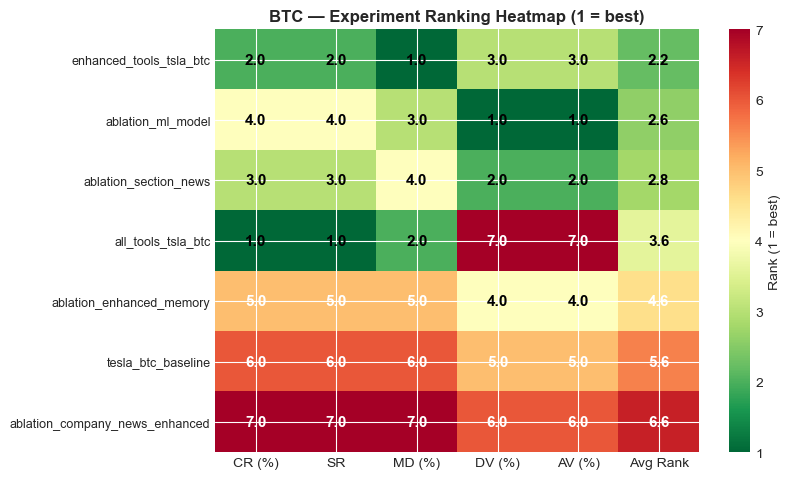

In [9]:
RANK_METRICS = {
    "CR (%)": True,  # higher is better
    "SR": True,
    "MD (%)": True,  # less negative is better (higher value)
    "DV (%)": False,  # lower is better
    "AV (%)": False,
}

for ticker in COMPARE_TICKERS:
    ticker_rows = summary_df[(summary_df["Ticker"] == ticker) & (~summary_df["Experiment"].str.startswith("Buy-and-Hold"))].copy()

    if len(ticker_rows) < 2:
        print(f"{ticker}: need ≥2 experiments to rank. Skipping heatmap.")
        continue

    ticker_rows = ticker_rows.set_index("Experiment")
    rank_df = pd.DataFrame(index=ticker_rows.index)

    for col, ascending_better_means_higher in RANK_METRICS.items():
        if col not in ticker_rows.columns:
            continue
        if ascending_better_means_higher:
            rank_df[col] = ticker_rows[col].rank(ascending=False).astype(int)
        else:
            rank_df[col] = ticker_rows[col].rank(ascending=True).astype(int)

    # Also compute average rank
    rank_df["Avg Rank"] = rank_df.mean(axis=1).round(2)
    rank_df = rank_df.sort_values("Avg Rank")

    fig, ax = plt.subplots(figsize=(max(6, len(rank_df.columns) * 1.4), max(3, len(rank_df) * 0.7)))
    im = ax.imshow(rank_df.values, cmap="RdYlGn_r", vmin=1, vmax=len(rank_df), aspect="auto")

    ax.set_xticks(range(len(rank_df.columns)))
    ax.set_xticklabels(rank_df.columns, fontsize=10)
    ax.set_yticks(range(len(rank_df.index)))
    ax.set_yticklabels(rank_df.index, fontsize=9)

    for i in range(len(rank_df.index)):
        for j in range(len(rank_df.columns)):
            val = rank_df.values[i, j]
            ax.text(
                j,
                i,
                f"{val}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if val > len(rank_df) * 0.6 else "black",
            )

    plt.colorbar(im, ax=ax, label="Rank (1 = best)")
    ax.set_title(f"{ticker} — Experiment Ranking Heatmap (1 = best)", fontweight="bold")
    plt.tight_layout()
    plt.show()

## 10. Final Summary

In [ ]:
print("=" * 90)
print("EXPERIMENT COMPARISON SUMMARY")
print("=" * 90)
print(f"Experiments : {[n for n, _ in valid]}")
print(f"Tickers     : {COMPARE_TICKERS}")
print()
print(summary_df.to_string(index=False))
print()

# Per-ticker winner by CR
for ticker in COMPARE_TICKERS:
    timing_rows = summary_df[(summary_df["Ticker"] == ticker) & (~summary_df["Experiment"].str.startswith("Buy-and-Hold"))]
    if len(timing_rows) == 0:
        continue
    best = timing_rows.loc[timing_rows["CR (%)"].idxmax()]
    worst = timing_rows.loc[timing_rows["CR (%)"].idxmin()]
    print(f"{ticker}  Best CR : {best['Experiment']}  ({best['CR (%)']:+.2f}%)")
    print(f"{ticker}  Worst CR: {worst['Experiment']}  ({worst['CR (%)']:+.2f}%)")
print("=" * 90)

EXPERIMENT COMPARISON SUMMARY
Experiments : ['tesla_btc_baseline', 'ablation_company_news_enhanced', 'ablation_ml_model']
Tickers     : ['TSLA', 'BTC']

                    Experiment Ticker  CR (%)  Ann. Ret (%)     SR  MD (%)  DV (%)  AV (%)
            tesla_btc_baseline   TSLA  -54.48        -42.14 -0.755  -65.84   3.351   53.19
            tesla_btc_baseline    BTC  -17.97        -12.86 -0.293  -32.51   1.941   30.81
ablation_company_news_enhanced   TSLA  -23.53        -17.01 -0.134  -53.70   3.058   48.54
ablation_company_news_enhanced    BTC  -18.53        -13.28 -0.299  -40.57   1.973   31.33
             ablation_ml_model   TSLA  -23.79        -17.21 -0.446  -41.49   1.955   31.03
             ablation_ml_model    BTC    0.83          0.58  0.154  -26.70   1.645   26.12
           Buy-and-Hold (TSLA)   TSLA  114.29         69.87  0.673  -53.77   5.131   81.46
            Buy-and-Hold (BTC)    BTC   47.07         30.76  0.421  -32.15   3.384   53.72

TSLA  Best CR : ablation_co